In [1]:
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.base import ClassifierMixin, TransformerMixin


## Data Download

In [2]:
# Download the consoldiated spam data set from kaggle; the kaggle API handles local caching
path = kagglehub.dataset_download("nitishabharathi/email-spam-dataset")

In [3]:
# Enron spam data set (extracted from emails obtained from the collapse of Enron in 2001 and subsequent
# investigation by the Federal Energy Regulatory Comission, released by Andrew McCallum, and later
# packaged for easier analysis by CMU
df_enron = pd.read_csv(f"{path}/enronSpamSubset.csv")

# Spam assassin data set, collated by Justin Mason between 2002-2003 as a **testing** resource 
# for spam filter developers.
df_spam_assassin = pd.read_csv(f"{path}/completeSpamAssassin.csv")

# LingSpam data set, collated by researcherss at NCSR Demokritos in 2000 from a linguistics mailing list
# as a benchmark for anti-spam filtering
df_lingspam = pd.read_csv(f"{path}/lingSpam.csv")

raw_data_sets = { 
    'Enron': df_enron,
    'Spam Assassin': df_spam_assassin,
    'LingSpam': df_lingspam
}

## Exploratory Data Analysis

In [4]:
# First pass analysis of data
def analyze_df(df : pd.DataFrame, label_col: str):
    summary = {}
    feature_cols = df.columns.drop(label_col)

    # Basic shape of the data
    summary["shape"]  = df.shape
    summary["dtypes"] = df.dtypes.to_dict()
    summary["sample"] = df.sample(min(5, len(df)), random_state=42)

    # Label distribution
    summary["label_counts"] = df[label_col].value_counts().to_dict()
    summary["label_mix"] = df[label_col].value_counts(normalize=True).to_dict()

    # Look for nulls
    summary["missing_values"] = df.isnull().sum().to_dict()

    # Look for duplicates
    summary["duplicate_rows"] = int(df.duplicated().sum())
    summary["duplicate_vals"] = {
        col: int(df[col].duplicated().sum()) for col in feature_cols
    }

    return summary

In [5]:
def build_comparison(summaries: dict[str, dict]) -> dict[str, pd.DataFrame]:
    tables = {}

    tables["Overview"] = pd.DataFrame({
        name: { 
            "rows": summary["shape"][0],
            "cols": summary["shape"][1],
            "duplicate_rows": summary["duplicate_rows"]
        }
        for name, summary in summaries.items()
    }).T

    tables["Label Counts"] = pd.DataFrame({
        name: summary["label_counts"] for name, summary in summaries.items()
    }).T

    tables["Label Mix"] = pd.DataFrame({
        name: summary["label_mix"] for name, summary in summaries.items()
    }).T

    tables["Missing Values"] = pd.DataFrame({
        name: summary["missing_values"] for name, summary in summaries.items()
    }).T


    

    return tables

In [6]:
analysis = { name: analyze_df(df, "Label") for name, df in raw_data_sets.items() }

comparison = build_comparison(analysis)
for k in comparison.keys():
    display(comparison[k].style.set_caption(k))

,rows,cols,duplicate_rows
Enron,10000,4,0
Spam Assassin,6046,3,0
LingSpam,2605,3,0


,1,0
Enron,5000,5000
Spam Assassin,1896,4150
LingSpam,433,2172


,1,0
Enron,0.500000,0.500000
Spam Assassin,0.313596,0.686404
LingSpam,0.166219,0.833781


,Unnamed: 0.1,Unnamed: 0,Body,Label
Enron,0.000000,0.000000,0.000000,0.000000
Spam Assassin,nan,0.000000,1.000000,0.000000
LingSpam,nan,0.000000,0.000000,0.000000


In [7]:
# Data in the Body column looks clean; let's validate that the ^Subject: [text]\n pattern is consistent
for name, df in raw_data_sets.items():
    print(f"[{name}] Percentage starting with Subject (case insensitive): {df['Body'].str.match(r"Subject:", case=False).mean()}")
    print(f"[{name}] Percentage starting with Subject (case sensitive):   {df['Body'].str.match(r"Subject:", case=True).mean()}")


[Enron] Percentage starting with Subject (case insensitive): 1.0
[Enron] Percentage starting with Subject (case sensitive):   1.0
[Spam Assassin] Percentage starting with Subject (case insensitive): 0.00016539861065167054
[Spam Assassin] Percentage starting with Subject (case sensitive):   0.0
[LingSpam] Percentage starting with Subject (case insensitive): 0.999616122840691
[LingSpam] Percentage starting with Subject (case sensitive):   0.999616122840691


## Data Cleaning

In [8]:
def prep_df(df : pd.DataFrame, name: str, body_col: str, subject_col : str = "Subject", label_col : str = "Label") -> pd.DataFrame:   
    # Drop any rows with an empty body column 
    df = df[df[body_col].notna()]

    # Look for the Body: column to be prefixed with Subject:, if so extract
    is_subject_prefixed = df[body_col].str.match(r"Subject:", case=False)
    parts = df[body_col].str.partition("\n")
    parts.columns = ['header', 'separator', 'body']

    # If subject prefixed, grab the Subject from the header, otherwise ""
    subject = parts["header"].str[len("Subject:"):].str.strip().where(is_subject_prefixed, "")
    body = parts["body"].where(is_subject_prefixed, df[body_col])
     
    df_prepped = pd.DataFrame()    
    df_prepped[subject_col] = subject
    df_prepped[body_col] = body
    df_prepped[label_col] = df[label_col]
    df_prepped.insert(0, "Source", name)
    
    return df_prepped


In [9]:
df_prepped_enron = prep_df(df_enron, "Enron", "Body", "Subject")
(df_prepped_enron["Subject"] == "").mean()

np.float64(0.0091)

## Feature Engineering

In [10]:
# Extract features outside of the structure of which words appear
def engineer_features(df : pd.DataFrame, subject_col : str = "Subject", body_col : str = "Body") -> pd.DataFrame:
    df = df.copy()

    for col, prefix in [(subject_col, "subject"), (body_col, "body")]:
        text = df[col].str

        # Text Length
        length = text.len()
        word_count = text.split().str.len()

        # Letters and captialization ratios
        alpha_count = text.count(r"[A-Za-z]")
        upper_count = text.count(r"[A-Z]")
        upper_ratio = (upper_count / alpha_count).fillna(0)

        # Digit Ratios
        digit_count = text.count(r"\d")
        digit_ratio = (digit_count / length).fillna(0)

        # Special characters
        exclaim_count = text.count("!")
        asterix_count = text.count(r"\*")
        question_count = text.count(r"\?")
        dollar_count = text.count(r"\$")

        # Flag for embedded urls
        has_http_url = text.contains(r"https?://", regex=True, case=False, na=False)
        has_web_url = text.contains(r"\bwww\.[a-zA-Z0-9]+\.[a-zA-Z]{2,}", regex=True, case=False, na=False)

        df[f"{prefix}_length"]        = length
        df[f"{prefix}_word_count"]    = word_count
        df[f"{prefix}_upper_ratio"]   = upper_ratio
        df[f"{prefix}_digit_ratio"]   = digit_ratio

        df[f"{prefix}_exclaim_count"] = exclaim_count
        df[f"{prefix}_dollar_count"]  = dollar_count
        df[f"{prefix}_asterix_count"]  = asterix_count
        df[f"{prefix}_question_count"]  = question_count

        df[f"{prefix}_has_http_url"]  = has_http_url
        df[f"{prefix}_has_web_url"]   = has_web_url

    df["has_subject"] = df[subject_col].str.len() > 0


    return df

In [11]:
df_enron_featured = engineer_features(df_prepped_enron)

In [12]:
def plot_feature_by_label(df, feature_col, label_col, ax=None, log_scale=False):   
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
        
    sns.boxplot(data=df, x=label_col, y=feature_col, ax=ax)
    ax.set_title(f"{feature_col} by {label_col}")

    if log_scale:
        ax.set_yscale("log")    


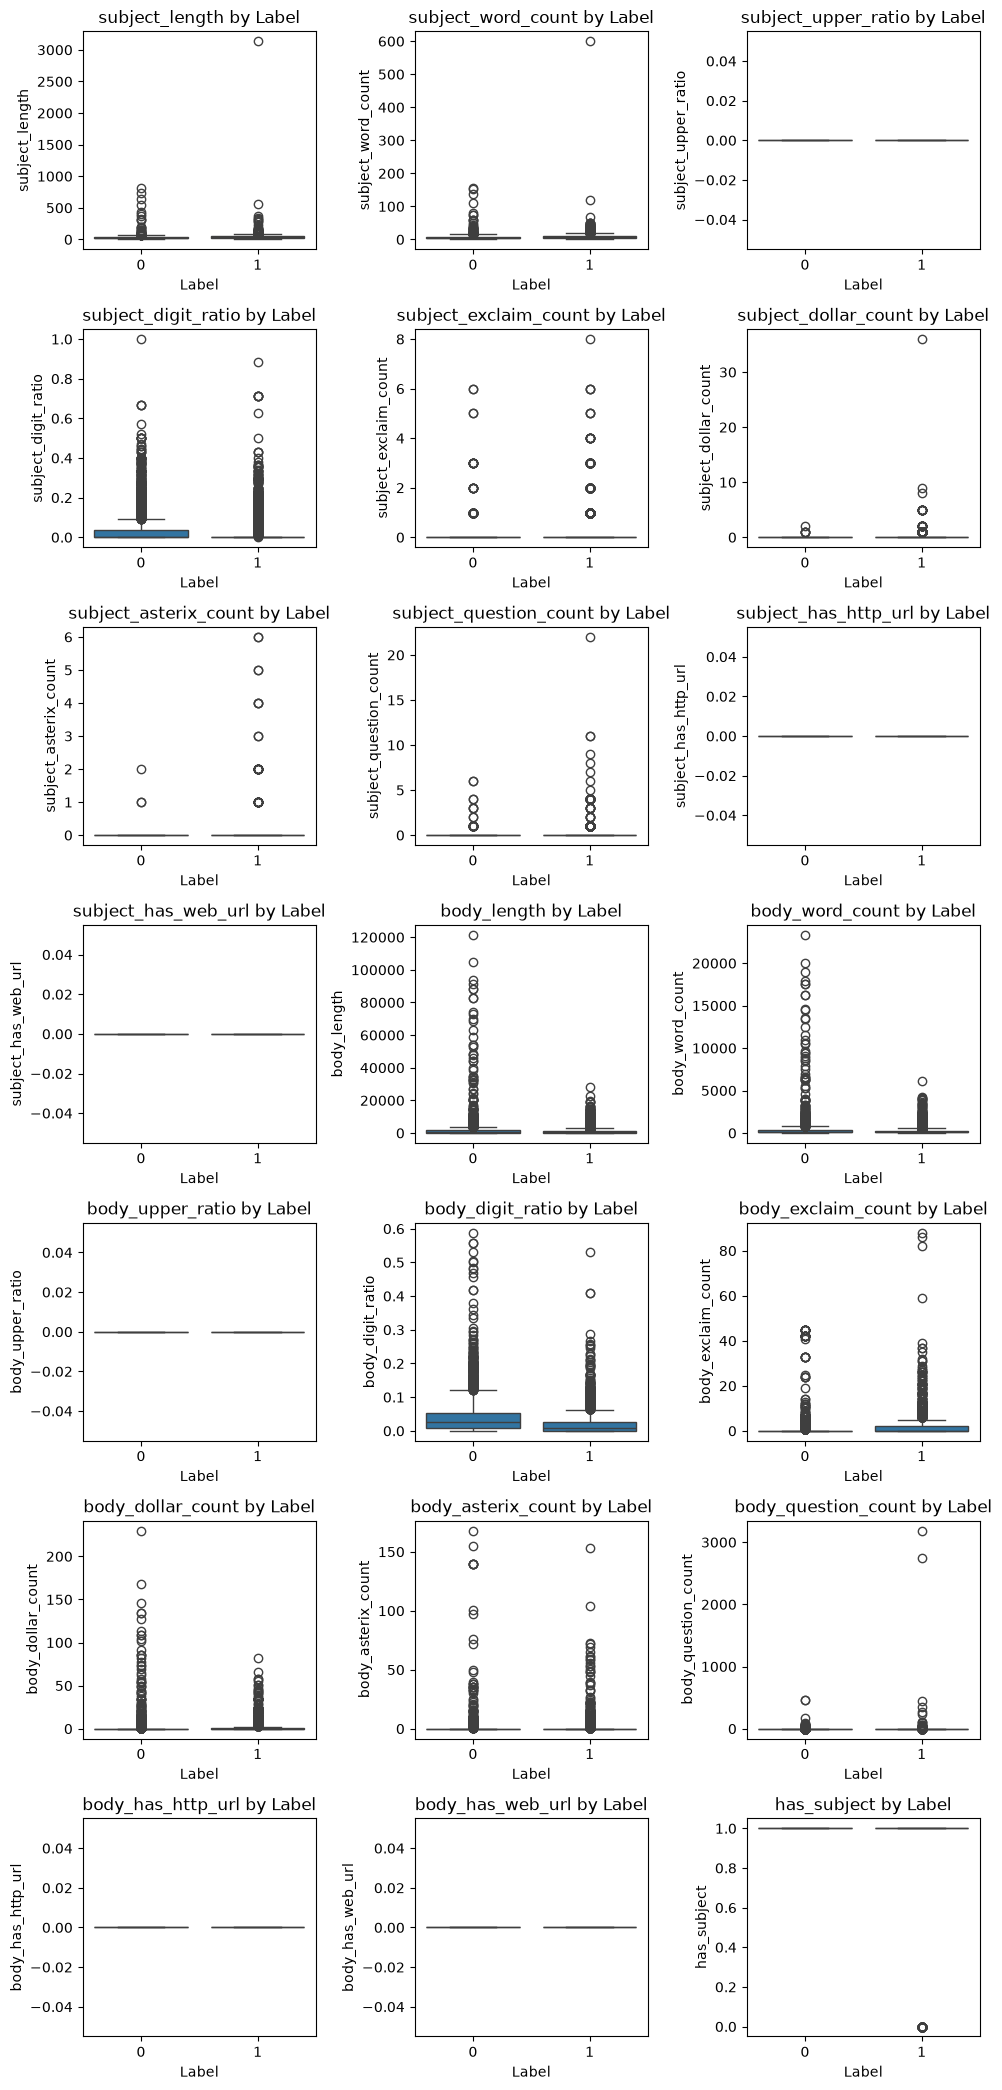

In [13]:
# Visualize all features (all columns other than Source, Subject, Body, Label)
exclude_cols = ["Source", "Subject", "Body", "Label"]
feature_cols = [c for c in df_enron_featured.columns if c not in exclude_cols]

import math

n_cols = 3
n_rows = math.ceil(len(feature_cols) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, 3 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(feature_cols):
    plot_feature_by_label(df_enron_featured, feature, "Label", ax=axes[i])

plt.tight_layout()
plt.show()

In [14]:
# Look for outliers in numeric feature columns
def find_outliers(df: pd.DataFrame, feature_cols: list[str], label_col : str) -> pd.DataFrame:
    feature_cols = df[feature_cols].select_dtypes(include="number").columns.tolist()
    rows = [ ] 
    
    for col in feature_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        is_outlier = (df[col] < lower_bound) | (df[col] > upper_bound)

        rows.append({
            "feature": col,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": int(is_outlier.sum()),
            "outlier_rate": is_outlier.mean(),
            "label_mix": df.loc[is_outlier, label_col].value_counts(normalize=True).to_dict()
        })

    return pd.DataFrame(rows)

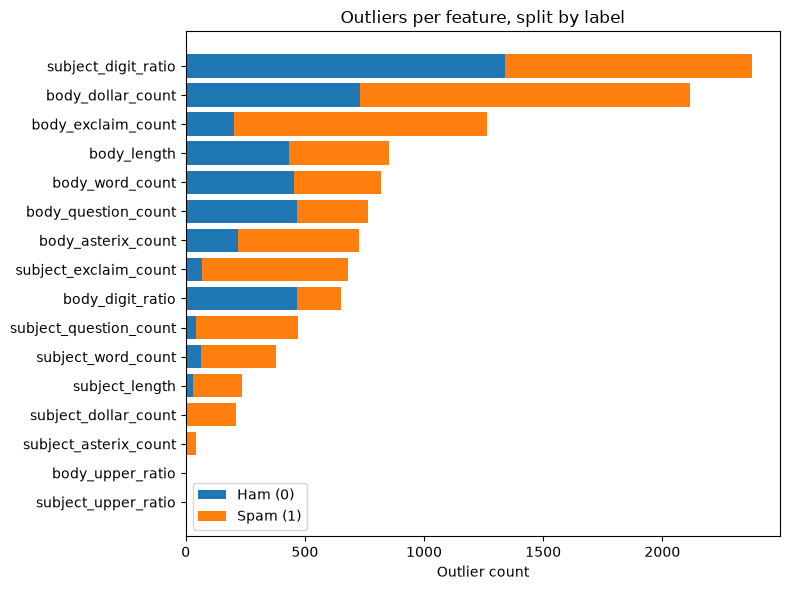

In [15]:
df_outlier_report = find_outliers(df_enron_featured, feature_cols, "Label")

df_outlier_report["ham_count"] = df_outlier_report.apply(
    lambda row: row["label_mix"].get(0, 0) * row["outlier_count"], axis=1
)
df_outlier_report["spam_count"] = df_outlier_report.apply(
    lambda row: row["label_mix"].get(1, 0) * row["outlier_count"], axis=1
)
df_outlier_report = df_outlier_report.sort_values("outlier_count")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(df_outlier_report["feature"], df_outlier_report["ham_count"], label="Ham (0)")
ax.barh(df_outlier_report["feature"], df_outlier_report["spam_count"], left=df_outlier_report["ham_count"], label="Spam (1)")
ax.set_xlabel("Outlier count")
ax.set_title("Outliers per feature, split by label")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Which features do not add signal
constant_features = [col for col in feature_cols if df_enron_featured[col].nunique() == 1]
df_enron_filtered = df_enron_featured.drop(columns=constant_features)


## Baseline Model

In [17]:
# Put the subject and body back together for a simpler starting point for vectorization
df_enron_filtered["text"] = df_enron_filtered["Subject"] + " " + df_enron_filtered["Body"]

# Check for and drop duplicates that could skew test/train splits
#dupe_count = df_enron_featured["text"].duplicated().sum() - 313/10,000
df_enron_filtered = df_enron_filtered.drop_duplicates(subset=["text"], keep="first")


In [18]:
df_train, df_test = train_test_split(
    df_enron_filtered, 
    test_size=0.2,
    stratify=df_enron_filtered["Label"],
    random_state=42
)

In [19]:
vectorizer = TfidfVectorizer(stop_words="english")
X_train = vectorizer.fit_transform(df_train["text"])
X_test = vectorizer.transform(df_test["text"])

In [20]:
# Per https://scikit-learn.org/stable/modules/naive_bayes.html, use Multinomial Naive Bayes as the 
# text data is multinomially distributed
base_model = MultinomialNB()
base_model.fit(X_train, df_train["Label"])

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3941.,3808.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.68,-0.71]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 76112)","[[49.1 ,42.63, 0.22,..., 0. , 0. , 0. ], [28.49,31.54, 6.17,..., 0.05, 0.05, 0.67]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 76112)","[[ -7.61, -7.75,-11.33,...,-11.53,-11.53,-11.53], [ -8.16, -8.07, -9.58,...,-11.5 ,-11.5 ,-11.04]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,76112


In [21]:
predictions = base_model.predict(X_test)
probability = base_model.predict_proba(X_test)[:, 1]

In [22]:
precision = precision_score(df_test["Label"], predictions)
recall = recall_score(df_test["Label"], predictions)
f1 = f1_score(df_test["Label"], predictions)
roc_auc = roc_auc_score(df_test["Label"], probability)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1:        {f1:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")

print(classification_report(df_test["Label"], predictions))

Precision: 0.993
Recall:    0.981
F1:        0.987
ROC-AUC:   0.999
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       986
           1       0.99      0.98      0.99       952

    accuracy                           0.99      1938
   macro avg       0.99      0.99      0.99      1938
weighted avg       0.99      0.99      0.99      1938



## Cross Data Set Validation

In [23]:
def evaluate_model(model : ClassifierMixin, vectorizer : TransformerMixin, df : pd.DataFrame, text_col : str, label_col : str):
    X = vectorizer.transform(df[text_col])
    predictions = model.predict(X)
    probability = model.predict_proba(X)[:, 1]

    return {
        "precision": precision_score(df[label_col], predictions),
        "recall": recall_score(df[label_col], predictions),
        "f1": f1_score(df[label_col], predictions),
        "roc_auc": roc_auc_score(df[label_col], probability),
        "confusion_matrix": confusion_matrix(df[label_col], predictions),
        "classification_report": classification_report(df[label_col], predictions, output_dict=True),
    }

In [24]:
results = {}

evaluation_data_sets = {    
    'Spam Assassin': df_spam_assassin,
    'LingSpam': df_lingspam
}

for name, df in evaluation_data_sets.items():
    df_a = prep_df(df, name, "Body", "Subject", "Label")
    df_b = engineer_features(df_a)

    constant_features = [col for col in feature_cols if df_b[col].nunique() == 1]
    df_c = df_b.drop(columns=constant_features)

    df_c['text'] = df_c["Subject"] + " " + df_c["Body"]
    df_ready = df_c.drop_duplicates(subset=["text"], keep="first")

    results[name] = evaluate_model(base_model, vectorizer, df_ready, "text", "Label")

results['Enron (Testing)'] = evaluate_model(base_model, vectorizer, df_test, "text", "Label")

metrics = ["precision", "recall", "f1", "roc_auc"]
rows = [
    {"dataset": name, "metric": metric, "value": result[metric]}
    for name, result in results.items()
    for metric in metrics
]
df_comparison = pd.DataFrame(rows)

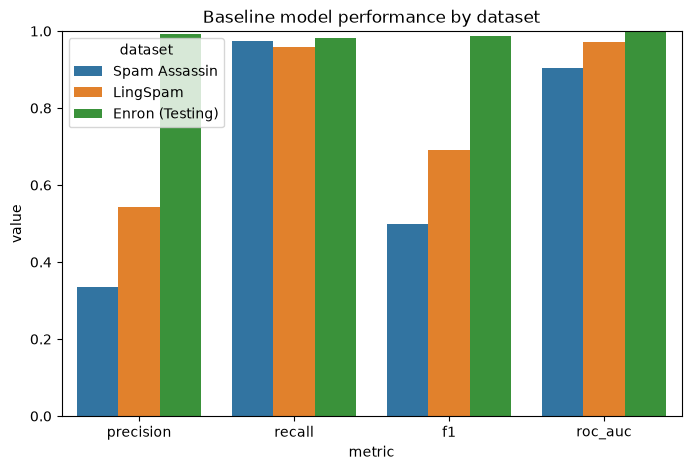

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_comparison, x="metric", y="value", hue="dataset", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Baseline model performance by dataset")
plt.show()


In [26]:
display(df_comparison)

,dataset,metric,value
0,Spam Assassin,precision,0.334580
1,Spam Assassin,recall,0.973875
2,Spam Assassin,f1,0.498052
3,Spam Assassin,roc_auc,0.903127
4,LingSpam,precision,0.542169
5,LingSpam,recall,0.957447
6,LingSpam,f1,0.692308
7,LingSpam,roc_auc,0.972629
8,Enron (Testing),precision,0.992561
9,Enron (Testing),recall,0.981092
